<a href="https://colab.research.google.com/github/BrunaLimaa/BrunaLimaa/blob/SDUAISHD/notebooks/01_Introducao_Segmentacao.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from skimage import data
from skimage.filters import threshold_otsu
from scipy import ndimage as ndi
from skimage.segmentation import watershed
from skimage.feature import peak_local_max
from sklearn.cluster import KMeans

# **Limiar (Threshold) + Watershed**

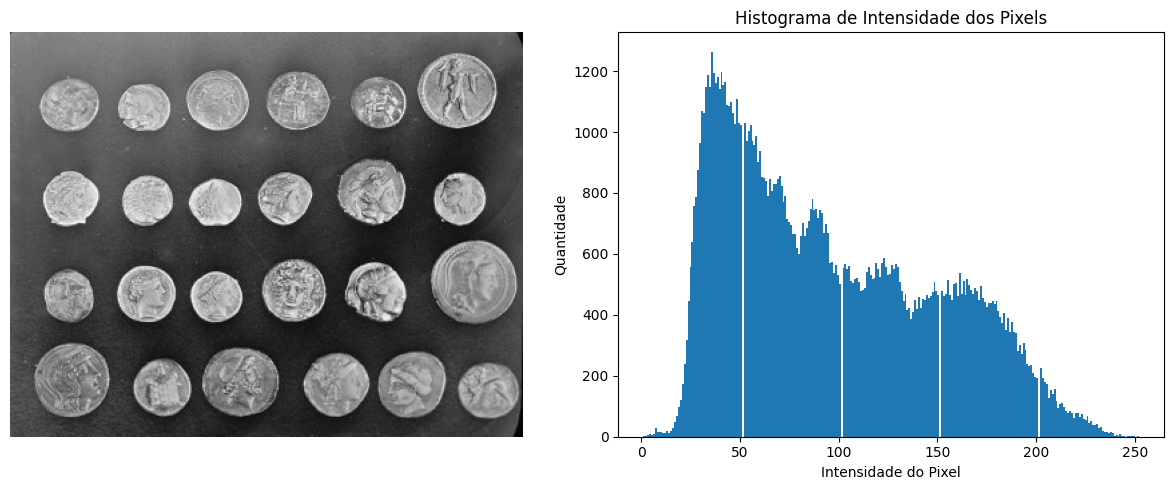

In [ ]:
image = data.coins()
fig, axes = plt.subplots(1,2, figsize=(12,5))
ax = axes.ravel()

ax[0].imshow(image, cmap=plt.cm.grey)
ax[0].axis('off')

ax[1].hist(image.ravel(), bins=256)
ax[1].set_title('Histograma de Intensidade dos Pixels')
ax[1].set_xlabel('Intensidade do Pixel')
ax[1].set_ylabel('Quantidade')

plt.tight_layout()
plt.show()

Valor do limiar: 107


(np.float64(-0.5), np.float64(383.5), np.float64(302.5), np.float64(-0.5))

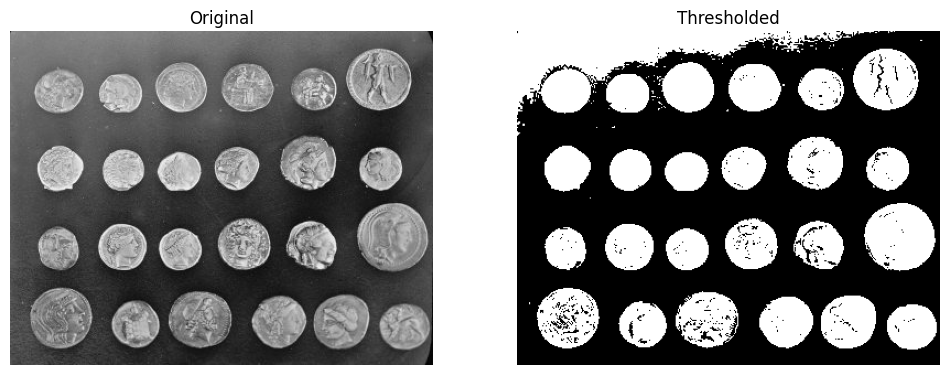

In [ ]:
thresh = threshold_otsu(image)
binary_mask = image > thresh
print(f"Valor do limiar: {thresh}")

fig, axes = plt.subplots(1,2, figsize=(12,5))
ax = axes.ravel()
ax[0].imshow(image, cmap='gray')
ax[0].set_title('Original')
ax[1].imshow(binary_mask, cmap='gray')
ax[1].set_title('Thresholded')

ax[0].axis('off')
ax[1].axis('off')

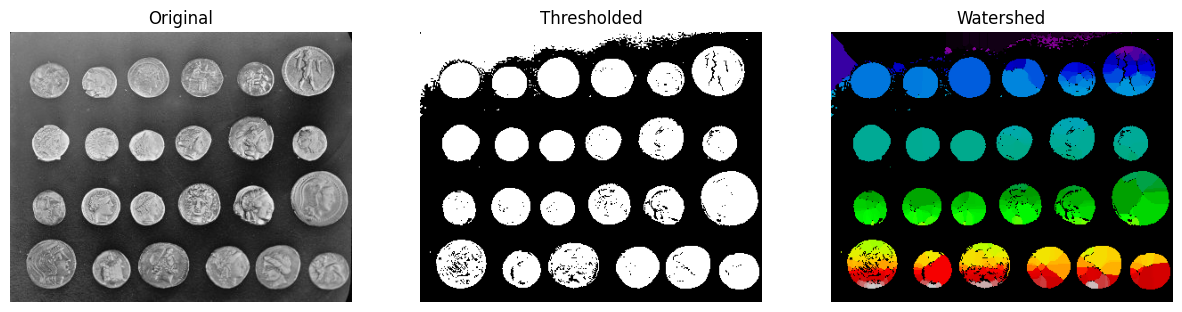

In [ ]:
#watershed
distance = ndi.distance_transform_edt(binary_mask)
coords = peak_local_max(distance, footprint=np.ones((3,3)), labels=binary_mask)
mask = np.zeros(distance.shape, dtype=bool)
mask[tuple(coords.T)] = True

markers, _ = ndi.label(mask)
labels = watershed(-distance, markers, mask=binary_mask)

fig, axes = plt.subplots(1,3, figsize=(15,4))
ax = axes.ravel()

ax[0].imshow(image, cmap='gray')
ax[0].set_title('Original')
ax[1].imshow(binary_mask, cmap='gray')
ax[1].set_title('Thresholded')
ax[2].imshow(labels, cmap=plt.cm.nipy_spectral)
ax[2].set_title('Watershed')

for a in ax:
    a.axis('off')



# **K-MEANS:**

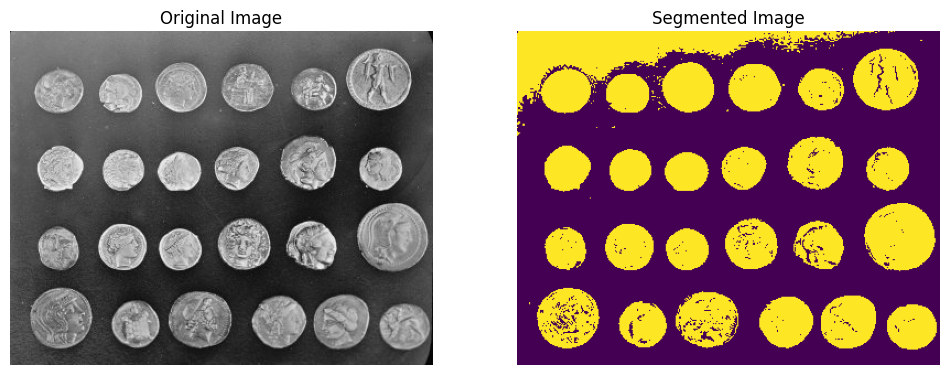

In [ ]:
pixels = image.flatten().reshape(-1,1)

kmeans = KMeans(n_clusters=2, random_state=42, n_init='auto').fit(pixels)

segmented_labels = kmeans.labels_

segmented_image = segmented_labels.reshape(image.shape)

fig, axes = plt.subplots(1,2, figsize=(12,5))
ax = axes.ravel()

ax[0].imshow(image, cmap=plt.cm.gray)
ax[1].imshow(segmented_image, cmap=plt.cm.viridis)
ax[0].set_title('Original Image')
ax[1].set_title('Segmented Image')
ax[0].axis('off')
ax[1].axis('off')
plt.show()


